# Assignment 6: Predictive Modeling of Housing Prices in Philadelphia

**Due date: Monday, 11/24 by the end of the day**

Tutorial 12.3, 13.1, 13.2 will cover predictive modeling of housing prices in Philadelphia. We'll extend that analysis in this section by:

- Optimizing our hyperparameters during the modeling process using cross-validation and a grid search
- Testing the fairness of our model by calculating the intersection of the model error rate and poverty rate across neighborhoods

## Modeling Philadelphia's Housing Prices and Algorithmic Fairness


In [68]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import hvplot.pandas

np.random.seed(42)

In [69]:
pd.options.display.max_columns = 999

### 2.1 Load data from the Office of Property Assessment

Use the requests package to query the CARTO API for **single-family** property assessment data in Philadelphia for properties that had their **last sale during 2022**.

Sources: 
- [OpenDataPhilly](https://www.opendataphilly.org/dataset/opa-property-assessments)
- [Metadata](http://metadata.phila.gov/#home/datasetdetails/5543865f20583086178c4ee5/representationdetails/55d624fdad35c7e854cb21a4/)

In [70]:
# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Pipelines
from sklearn.pipeline import make_pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [71]:
# The CARTO API url
carto_url = "https://phl.carto.com/api/v2/sql"

# Only pull 2022 sales for single family residential properties
where = "sale_date >= '2022-01-01' and sale_date <= '2022-12-31'"
where = where + " and category_code_description IN ('SINGLE FAMILY', 'Single Family')"

# Create the query
query = f"SELECT * FROM opa_properties_public WHERE {where}"

# Make the request
params = {"q": query, "format": "geojson"}
response = requests.get(carto_url, params=params)

# Create the GeoDataFrame from the API response
sales_gdf = gpd.GeoDataFrame.from_features(response.json(), crs="EPSG:4326")

# CRITICAL STEP: Reproject to Philadelphia's local projection (EPSG:2272)
# This ensures accurate spatial operations later
sales_gdf = sales_gdf.to_crs(epsg=2272)

# Convert key columns to numeric (API returns them as strings sometimes)
numeric_cols = ['sale_price', 'total_livable_area', 'number_of_bedrooms', 
                'number_of_bathrooms', 'number_stories', 'market_value']
for col in numeric_cols:
    sales_gdf[col] = pd.to_numeric(sales_gdf[col], errors='coerce')

# Optional: Sort for reproducibility
sales_gdf = sales_gdf.sort_values("parcel_number")

print(f"Loaded {len(sales_gdf)} rows.")
sales_gdf.head()

Loaded 25193 rows.


,geometry,cartodb_id,assessment_date,basements,beginning_point,book_and_page,building_code,building_code_description,category_code,category_code_description,census_tract,central_air,cross_reference,date_exterior_condition,depth,exempt_building,exempt_land,exterior_condition,fireplaces,frontage,fuel,garage_spaces,garage_type,general_construction,geographic_ward,homestead_exemption,house_extension,house_number,interior_condition,location,mailing_address_1,mailing_address_2,mailing_care_of,mailing_city_state,mailing_street,mailing_zip,market_value,market_value_date,number_of_bathrooms,number_of_bedrooms,number_of_rooms,number_stories,off_street_open,other_building,owner_1,owner_2,parcel_number,parcel_shape,quality_grade,recording_date,registry_number,sale_date,sale_price,separate_utilities,sewer,site_type,state_code,street_code,street_designation,street_direction,street_name,suffix,taxable_building,taxable_land,topography,total_area,total_livable_area,type_heater,unfinished,unit,utility,view_type,year_built,year_built_estimate,zip_code,zoning,pin,building_code_new,building_code_description_new,objectid
1539,POINT (2697800.376 226998.824),63276,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,18.0,A,2.0,1,B,1,0,None,1632,1,1632 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000029,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,1079.0,2790.0,A,None,None,None,I,2024,None,19148,CMX1,1001684829,25,ROW MODERN,721298016
1536,POINT (2697796.232 226977.564),63273,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,20.0,A,2.0,1,B,1,0,None,1634,1,1634 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000030,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,987.0,2580.0,A,None,None,None,I,2024,None,19148,CMX1,1001684830,25,ROW MODERN,721298013
1537,POINT (2697791.485 226957.745),63274,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,20.0,A,2.0,1,B,1,0,None,1636,1,1636 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000031,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,985.0,2580.0,A,None,None,None,I,2024,None,19148,CMX1,1001684831,25,ROW MODERN,721298014
1538,POINT (2697785.627 226937.528),63275,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,47.0,660000.0,0.0,1,NaN,19.0,A,2.0,1,B,1,0,None,1638,1,1638 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000032,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,1050.0,2655.0,A,None,None,None,I,2024,None,19148,CMX1,1001684832,25,ROW MODERN,721298015
944,POINT (2697937.481 228630.457),62495,2024-05-30T00:00:00Z,0,"36'6"" E OF AMERICAN",54131081,R30,ROW B/GAR 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,90.0,0.0,0.0,4,1.0,18.0,A,1.0,1,A,1,0,None,224,4,224 WHARTON ST,SIMPLIFILE LC E-RECORDING,None,None,PHILADELPHIA PA,224 WHARTON ST,19147-5336,463000,None,2.0,3.0,NaN,3.0,711.0,None,DEVER CATHERINE JOAN,None,011001670,E,C,2022-12-14T00:00:00Z,9S17 307,2022-12-05T00:00:00Z,450000.0,None,0,None,PA,82740,ST,None,WHARTON,None,370400.0,92600.0,F,1625.0,1785.0,A,None,None,None,I,1960,Y,19147,RSA5,1001563093,23,ROW POST WAR,721298721


### 2.2 Load data for census tracts and neighborhoods

Load various Philadelphia-based regions that we will use in our analysis. 

Census tracts can be downloaded and Neighborhoods can be downloaded from [here](assignment6-data.zip). Please unzip the file and put in the same folder as your notebook.


In [72]:
# Load Census Tracts (Ensure the filename matches your local file)
tracts = gpd.read_file('data/Census_Tracts_2010.geojson')
tracts = tracts.to_crs(epsg=2272)

# Load Neighborhoods
neighborhoods = gpd.read_file('data/philadelphia-neighborhoods.geojson')
neighborhoods = neighborhoods.to_crs(epsg=2272)

# Verify coordinate systems match
print("Tracts CRS:", tracts.crs)
print("Neighborhoods CRS:", neighborhoods.crs)

Tracts CRS: EPSG:2272
Neighborhoods CRS: EPSG:2272


### 2.3 Spatially join the sales data and neighborhoods/census tracts.

Perform a spatial join, such that each sale has an associated neighborhood and census tract.

**Note:** After performing the first spatial join, you will need to use the `drop()` function to remove the `index_right` column; otherwise an error will be raised on the second spatial join about duplicate columns.

In [73]:
print(neighborhoods.columns)
print(tracts.columns)
print(sales_gdf.columns)

Index(['NAME', 'LISTNAME', 'MAPNAME', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')
Index(['OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'geometry'],
      dtype='object')
Index(['geometry', 'cartodb_id', 'assessment_date', 'basements',
       'beginning_point', 'book_and_page', 'building_code',
       'building_code_description', 'category_code',
       'category_code_description', 'census_tract', 'central_air',
       'cross_reference', 'date_exterior_condition', 'depth',
       'exempt_building', 'exempt_land', 'exterior_condition', 'fireplaces',
       'frontage', 'fuel', 'garage_spaces', 'garage_type',
       'general_construction', 'geographic_ward', 'homestead_exemption',
       'house_extension', 'house_number', 'interior_condition', 'location',
       'mailing_address_1', 'mailing_address_2', 'mailing_care_of',
       'mailin

In [74]:
# Join with neighborhoods
sales_neigh = gpd.sjoin(
    sales_gdf,
    neighborhoods[['NAME', 'geometry']],
    how='left',
    predicate='within'
).rename(columns={"NAME": "neighborhood_name"}).drop(columns=['index_right'])

# Join with tracts
sales_full = gpd.sjoin(
    sales_neigh,
    tracts[['GEOID10', 'geometry']],
    how='left',
    predicate='within'
).rename(columns={"geometry": "tract_geometry"}).drop(columns=['index_right'])

# Restore sale point geometry
sales_full = sales_full.rename(columns={'tract_geometry': 'sale_geometry'})
sales_full = sales_full.set_geometry('sale_geometry')

sales_full.head()

,sale_geometry,cartodb_id,assessment_date,basements,beginning_point,book_and_page,building_code,building_code_description,category_code,category_code_description,census_tract,central_air,cross_reference,date_exterior_condition,depth,exempt_building,exempt_land,exterior_condition,fireplaces,frontage,fuel,garage_spaces,garage_type,general_construction,geographic_ward,homestead_exemption,house_extension,house_number,interior_condition,location,mailing_address_1,mailing_address_2,mailing_care_of,mailing_city_state,mailing_street,mailing_zip,market_value,market_value_date,number_of_bathrooms,number_of_bedrooms,number_of_rooms,number_stories,off_street_open,other_building,owner_1,owner_2,parcel_number,parcel_shape,quality_grade,recording_date,registry_number,sale_date,sale_price,separate_utilities,sewer,site_type,state_code,street_code,street_designation,street_direction,street_name,suffix,taxable_building,taxable_land,topography,total_area,total_livable_area,type_heater,unfinished,unit,utility,view_type,year_built,year_built_estimate,zip_code,zoning,pin,building_code_new,building_code_description_new,objectid,neighborhood_name,GEOID10
1539,POINT (2697800.376 226998.824),63276,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,18.0,A,2.0,1,B,1,0,None,1632,1,1632 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000029,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,1079.0,2790.0,A,None,None,None,I,2024,None,19148,CMX1,1001684829,25,ROW MODERN,721298016,PENNSPORT,42101002702
1536,POINT (2697796.232 226977.564),63273,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,20.0,A,2.0,1,B,1,0,None,1634,1,1634 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000030,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,987.0,2580.0,A,None,None,None,I,2024,None,19148,CMX1,1001684830,25,ROW MODERN,721298013,PENNSPORT,42101002702
1537,POINT (2697791.485 226957.745),63274,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,48.0,660000.0,0.0,1,NaN,20.0,A,2.0,1,B,1,0,None,1636,1,1636 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000031,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,985.0,2580.0,A,None,None,None,I,2024,None,19148,CMX1,1001684831,25,ROW MODERN,721298014,PENNSPORT,42101002702
1538,POINT (2697785.627 226937.528),63275,2024-09-12T00:00:00Z,A,N W C MORRIS,54134182,BB0,STR/OFF 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,47.0,660000.0,0.0,1,NaN,19.0,A,2.0,1,B,1,0,None,1638,1,1638 S 2ND ST,URBAN REAL ESTATE INVESTMENT INC,None,None,WEST POINT PA,None,19486,825000,None,NaN,4.0,7.0,3.0,816.0,None,URBAN REAL ESTATE INVESTMENT INC,None,011000032,A,None,2022-12-23T00:00:00Z,012S080034,2022-12-07T00:00:00Z,1.0,None,None,None,PA,87840,ST,S,2ND,None,0.0,165000.0,F,1050.0,2655.0,A,None,None,None,I,2024,None,19148,CMX1,1001684832,25,ROW MODERN,721298015,PENNSPORT,42101002702
944,POINT (2697937.481 228630.457),62495,2024-05-30T00:00:00Z,0,"36'6"" E OF AMERICAN",54131081,R30,ROW B/GAR 2 STY MASONRY,1,SINGLE FAMILY,27,Y,None,None,90.0,0.0,0.0,4,1.0,18.0,A,1.0,1,A,1,0,None,224,4,224 WHARTON ST,SIMPLIFILE LC E-RECORDING,None,None,PHILADELPHIA PA,224 WHARTON ST,19147-5336,463000,None,2.0,3.0,NaN,3.0,711.0,None,DEVER CATHERINE JOAN,None,011001670,E,C,2022-12-14T00:00:00Z,9S17 307,2022-12-05T00:00:00Z,450000.0,None,0,None,PA,82740,ST,None,WHART

### 2.4 Train a Random Forest on the sales data

In this step, you should follow the steps outlined in lecture to preprocess and train your model. We'll extend our analysis to do a hyperparameter grid search to find the best model configuration. As you train your model, follow the following steps:

**Preprocessing Requirements**
- Trim the sales data to those sales with prices between $3,000 and $1 million
- Set up a pipeline that includes both numerical columns and categorical columns
- Include one-hot encoded variable for the *neighborhood* of the sale, **instead of ZIP code**. We don't want to include multiple location based categories, since they encode much of the same information.

**Training requirements**
- Use a 70/30% training/test split and predict the log of the sales price.
- Use GridSearchCV to perform a k-fold cross validation that optimize *at least 2* hyperparameters of the RandomForestRegressor
- After fitting your model and finding the optimal hyperparameters, you should evaluate the score (R-squared) on the test set (the original 30% sample withheld)

**Note**: You don't need to include additional features (such as spatial distance features) or perform any extra feature engineering beyond what is required above to receive full credit. Of course, you are always welcome to experiment!

In [75]:
sales_model = sales_full[
    (sales_full['sale_price'] >=3000) &
    (sales_full['sale_price'] <=1000000)
].copy()

sales_model["log_price"] = np.log(sales_model["sale_price"])

num_features = [
    "total_livable_area",
    "total_area",
    "garage_spaces",
    "fireplaces",
    "number_of_bathrooms",
    "number_of_bedrooms",
    "number_stories",
    "exterior_condition",
]

# Keep only those that exist
num_features = [col for col in num_features if col in sales_model.columns]

cat_features = [
    "neighborhood_name",
    ]



In [76]:
# Remove rows with missing values in the features we plan to use
cols_for_model = num_features + cat_features

sales_model_clean = sales_model.dropna(subset=cols_for_model + ["log_price"]).copy()

x = sales_model_clean[cols_for_model]
y = sales_model_clean["log_price"]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [77]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine numeric + categorical preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# Define the model
rf = RandomForestRegressor(random_state=42)

# Create the pipeline
pipe = make_pipeline(preprocess, rf)

# Define hyperparameters for GridSearch
param_grid = {
    "randomforestregressor__n_estimators": [100, 200],
    "randomforestregressor__max_depth": [10, None],
}

#run GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring="r2",
    verbose=1,
)

grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)

# Evaluate on test set
best_model = grid.best_estimator_
y_pred_test_log = best_model.predict(x_test)

test_r2 = r2_score(y_test, y_pred_test_log)
print("Test R^2 (log price):", test_r2)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__n_estimators': 200}
Test R^2 (log price): 0.5836081740848407


### 2.5 Calculate the percent error of your model predictions for each sale in the test set

Fit your best model and use it to make predictions on the test set.

**Note:** This should be the percent error in terms of **sale price**. You'll need to convert if your model predicted the log of sales price!

In [78]:
# Use the best model to make predictions on the test set
y_pred_test_log = best_model.predict(x_test)

# Convert both true and predicted values from log(price) back to price
y_test_price = np.exp(y_test)            # true sale prices
y_pred_price = np.exp(y_pred_test_log)   # predicted sale prices

# Build a DataFrame aligned with the test indices
test_results = pd.DataFrame({
    "true_price": y_test_price,
    "pred_price": y_pred_price,
}, index=x_test.index)

#  Compute percent error for each sale
#    percent error = (pred - true) / true * 100
test_results["pct_error"] = (
    (test_results["pred_price"] - test_results["true_price"])
    / test_results["true_price"]
) * 100

# Look at the first few rows and some summary stats
display(test_results.head())
print("Median percent error:", test_results["pct_error"].median())
print("Median absolute percent error:", test_results["pct_error"].abs().median())

,true_price,pred_price,pct_error
9545,70000.0,170799.189723,143.998842
1560,550000.0,570123.959739,3.658902
10059,130000.0,302211.272428,132.470210
7422,235000.0,228640.517738,-2.706163
6895,185000.0,112729.455494,-39.065159


Median percent error: -3.2681370635047786
Median absolute percent error: 19.425055420138072


### 2.6 Make a data frame with percent errors and census tract info for each sale in the test set

Create a data frame that has the property geometries, census tract data, and percent errors for all of the sales in the test set.

**Notes**

- When using the "train_test_split()" function, the index of the test data frame includes the labels from the original sales data frame
- You can use this index to slice out the test data from the original sales data frame, which should include the census tract info and geometries
- Add a new column to this data frame holding the percent error data
- Make sure to use the percent error and not the absolute percent error



In [79]:

# Extract the test rows from the original sales_full GeoDataFrame
#    x_test.index contains the original row labels from sales_full
test_sales_full = sales_full.loc[x_test.index].copy()

# Add the percent error column created in 2.5
test_sales_full["pct_error"] = test_results.loc[x_test.index, "pct_error"]

#  Make sure it remains a GeoDataFrame with the correct geometry
test_sales_gdf = gpd.GeoDataFrame(
    test_sales_full,
    geometry="sale_geometry",
    crs=sales_full.crs
)

#  Display a few rows to verify
test_sales_gdf[["sale_price", "pct_error", "neighborhood_name", "GEOID10", "sale_geometry"]].head()


,sale_price,pct_error,neighborhood_name,GEOID10,sale_geometry
9545,70000.0,143.998842,FELTONVILLE,42101028901,POINT (2705599.882 261778.866)
1560,550000.0,3.658902,WASHINGTON_SQUARE,42101001102,POINT (2694823.405 233126.818)
10059,130000.0,132.470210,WASHINGTON_SQUARE,42101000902,POINT (2695703.546 233951.517)
7422,235000.0,-2.706163,MAYFAIR,42101031502,POINT (2721672.382 267989.286)
6895,185000.0,-39.065159,STRAWBERRY_MANSION,42101015102,POINT (2689032.544 248591.183)


### 2.8 Plot a map of the median percent error by census tract 

- You'll want to group your data frame of test sales by the `GEOID10` column and take the median of you percent error column
- Merge the census tract geometries back in and use geopandas to plot.

In [80]:
# Group test sales by census tract and compute the median percent error
tract_error = (
    test_sales_gdf
    .dropna(subset=["GEOID10", "pct_error"])
    .groupby("GEOID10")["pct_error"]
    .median()
    .reset_index(name="median_pct_error")
)

# Merge the tract-level errors back onto the tract geometries
tracts_error = tracts.merge(tract_error, on="GEOID10", how="left")

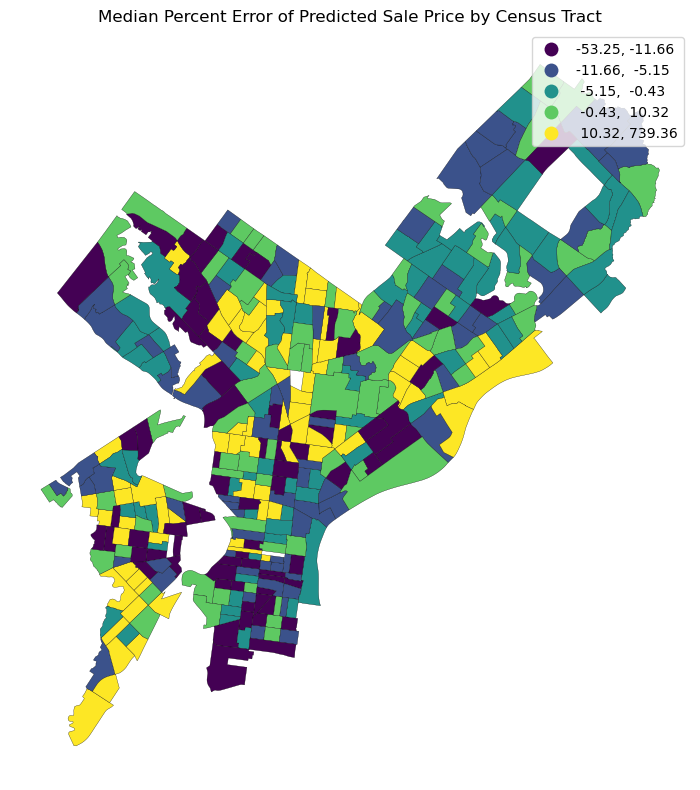

In [81]:
# Plot a choropleth map of median percent error by tract
fig, ax = plt.subplots(figsize=(10, 8))

tracts_error.plot(
    column="median_pct_error",
    legend=True,
    scheme="quantiles",   # or "NaturalBreaks", "equal_interval", etc.
    k=5,                  # number of classes
    linewidth=0.2,
    edgecolor="black",
    ax=ax
)

ax.set_title("Median Percent Error of Predicted Sale Price by Census Tract")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### 2.9 Compare the percent errors in Qualifying Census Tracts and other tracts 

[Qualifying Census Tracts](https://www.huduser.gov/portal/datasets/qct.html) are a poverty designation that HUD uses to allocate housing tax credits

- I've included a list of the census tract names that qualify in Philadelphia
- Add a new column to your dataframe of test set sales that is True/False depending on if the tract is a QCT
- Then, group by this new column and calculate the median percent error

**You should find that the algorithm's accuracy is significantly worse in these low-income, qualifying census tracts**

In [82]:
qct = ['5',
 '20',
 '22',
 '28.01',
 '30.01',
 '30.02',
 '31',
 '32',
 '33',
 '36',
 '37.01',
 '37.02',
 '39.01',
 '41.01',
 '41.02',
 '56',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '69',
 '70',
 '71.01',
 '71.02',
 '72',
 '73',
 '74',
 '77',
 '78',
 '80',
 '81.01',
 '81.02',
 '82',
 '83.01',
 '83.02',
 '84',
 '85',
 '86.01',
 '86.02',
 '87.01',
 '87.02',
 '88.01',
 '88.02',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '98.01',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '119',
 '121',
 '122.01',
 '122.03',
 '131',
 '132',
 '137',
 '138',
 '139',
 '140',
 '141',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '151.01',
 '151.02',
 '152',
 '153',
 '156',
 '157',
 '161',
 '162',
 '163',
 '164',
 '165',
 '167.01',
 '167.02',
 '168',
 '169.01',
 '169.02',
 '170',
 '171',
 '172.01',
 '172.02',
 '173',
 '174',
 '175',
 '176.01',
 '176.02',
 '177.01',
 '177.02',
 '178',
 '179',
 '180.02',
 '188',
 '190',
 '191',
 '192',
 '195.01',
 '195.02',
 '197',
 '198',
 '199',
 '200',
 '201.01',
 '201.02',
 '202',
 '203',
 '204',
 '205',
 '206',
 '208',
 '239',
 '240',
 '241',
 '242',
 '243',
 '244',
 '245',
 '246',
 '247',
 '249',
 '252',
 '253',
 '265',
 '267',
 '268',
 '271',
 '274.01',
 '274.02',
 '275',
 '276',
 '277',
 '278',
 '279.01',
 '279.02',
 '280',
 '281',
 '282',
 '283',
 '284',
 '285',
 '286',
 '287',
 '288',
 '289.01',
 '289.02',
 '290',
 '291',
 '293',
 '294',
 '298',
 '299',
 '300',
 '301',
 '302',
 '305.01',
 '305.02',
 '309',
 '311.01',
 '312',
 '313',
 '314.01',
 '314.02',
 '316',
 '318',
 '319',
 '321',
 '325',
 '329',
 '330',
 '337.01',
 '345.01',
 '357.01',
 '376',
 '377',
 '380',
 '381',
 '382',
 '383',
 '389',
 '390']

In [83]:
# Function to extract the tract code from GEOID10 and match the style in the QCT list
def extract_tract_id(geoid):
    """
    Converts a full GEOID10 (e.g., '42101003001') into the short tract ID used in the QCT list.
    Generally this takes the last 6 digits and removes leading zeros.
    """
    geoid_str = str(geoid)
    short = geoid_str[-6:]         # Take last 6 digits
    short = short.lstrip("0")      # Remove leading zeros (important!)
    return short

# Apply this function to create a short tract code
test_sales_gdf["tract_short"] = test_sales_gdf["GEOID10"].apply(extract_tract_id)

# Add True/False column for whether this tract is a QCT
test_sales_gdf["is_qct"] = test_sales_gdf["tract_short"].isin(qct)

# Group by QCT vs. non-QCT and compute median percent error
qct_comparison = (
    test_sales_gdf
    .groupby("is_qct")["pct_error"]
    .median()
    .reset_index(name="median_pct_error")
)

qct_comparison

,is_qct,median_pct_error
0,False,-3.294936
1,True,-0.366784
